In [1]:
print("gello")

gello


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_loader import load_feature_lists
import sys
# loads the col
FEATURE_CONFIG_PATH = "utils/feature_columns.json"
feature_lists = load_feature_lists(FEATURE_CONFIG_PATH)
Liste_features_simple = feature_lists["Liste_features_simple"]
features_radiology_dysfunction = feature_lists["features_radiology_dysfunction"]
features_etiology = feature_lists["features_etiology"]
features_death = feature_lists["death"]
# Charger le fichier Excel
df = pd.read_excel(r"C:\Users\romai\Desktop\travail\EFRAIM3 JD VANCE.xlsx")

# séparer colonnes explicatives et etiology
df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')
Liste_features = Liste_features_simple + features_radiology_dysfunction
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
df_death = df[features_death]
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
sys.modules.pop('utils.feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)

df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean,index_a_drop = nettoyer_lignes_vides(df_category)
df_features_clean = df_features_clean.drop(index=index_a_drop)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)


🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (88.0)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 3055


In [3]:
import sys
sys.modules.pop('utils.feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)

sys.modules.pop('utils.visualisation', None)
sys.modules.pop('evaluation.evaluation', None)
sys.modules.pop('utils.data_aug', None)
sys.modules.pop('utils.models_and_metrics', None) 

In [4]:
L = df_features_clean.columns
print(L)
print(df_features_clean.dtypes)

Index(['Sex', 'Time H-ICU', 'TIME SYMPTOMES-ICU', 'Time  DG-ICU',
       'Dis_status HEM', 'Sys_dis', 'Solid_tumor', 'Organ_transpl',
       'Drug_induced', 'Chemotherapy', 'Ibr_Flu_Met', 'Immuno_drugs',
       'Tar_ther', 'Immunotherapy', 'Carttcells', 'Steroids_YN',
       'Charlson_index', 'Prophylaxis_pneumocystis', 'Prophylaxis_antifungal',
       'Prophylaxis_bacterial', 'Prophylaxis_viral', 'Vaccins#Flu',
       'Vaccins#COVID', 'Vaccins#Other', 'Glasgow', 'Hemoptysis',
       'PaO2/FiO2 VALUE VALUE', 'Pleural_eff', 'Quad_no', 'Excavation',
       'Septal_line', 'Halo_sign', 'Crazy_paving', 'Lymph_bulky', 'Age_scaled',
       'Hem_mal_AML', 'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma',
       'Hem_mal_myeloma', 'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL',
       'Hem_mal_CML', 'Hem_mal_MDS', 'Hem_mal_other',
       'Disease_status_inaugural', 'Disease_status_remission',
       'Disease_status_evolutive', 'Alveolar_xray_Focal',
       'Alveolar_xray_Diffuse', 'Interst_xray_Focal',

# Mapping classes

In [5]:
# format mapping_etiology[nvelle_col] = [old_col1,old_cold2 ,...]
mapping_etiology ={
                    'Bacterial infection' :['Bacterial infection'] ,
                    'Viral infection' :['Viral infection'] ,
                    'Invasive pulmonary aspergillosis' :['Invasive pulmonary aspergillosis'] ,
                    'Other fungal' :["Other fungal "] ,
                    'Mucorales' : ['Mucorales'],
                    'Pneumocystis jirovecii infection' :[ 'Pneumocystis jirovecii infection'],
                    'Cardiogenic pulmonary oedema' : ['Cardiogenic pulmonary oedema'],
                    'Disease-related infiltrates':['Disease-related infiltrates'],
                    'Drug toxicity related' : ['Drug toxicity related'],
                    'Other non infectious causes': ['Other non infectious causes','Other infection ','Transfusion-related acute lung injury'],
                   # 'Undetermined cause':['Undetermined cause' ]
                    }
from utils.data_quality import fusionner_labels
print(df_cat_clean.columns)
df_labels_fusion = fusionner_labels(df_cat_clean, mapping_etiology, mode="max")

Index(['Bacterial infection', 'Viral infection',
       'Invasive pulmonary aspergillosis', 'Pneumocystis jirovecii infection',
       'Mucorales', 'Other fungal ', 'Other infection ',
       'Cardiogenic pulmonary oedema', 'Drug toxicity related',
       'Disease-related infiltrates', 'Transfusion-related acute lung injury',
       'Other non infectious causes'],
      dtype='object')


# Model 1 classe

False
True
False
True
True
False



📊 Répartition des classes : pos=0.132, neg=0.868
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

==== Cardiogenic pulmonary oedema ====
Logistic Regression AUC: 0.7482854554865424
Negative Predictive Value: 0


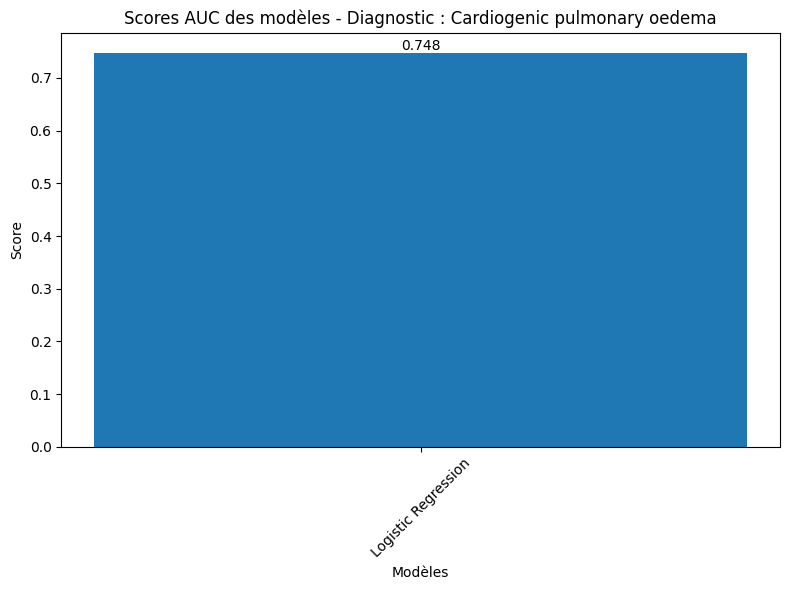

In [58]:
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline
sys.modules.pop('utils.visualisation')
from utils.algo_prediction import preparer_jeu_xy, AutoStandardScaler
from utils.models_and_metrics import get_models, get_metric, negative_predictive_value
from utils.data_aug import get_augmentation_methods
from utils.visualisation import show_metrics_binary, show_roc_curve,plot_model_bars
from utils.analyse_sensibilite import analyse_sensibilite

def run_for_target(df_features_clean, 
                   df_labels_fusion, 
                   target_col,
                   MODEL_NAMES,
                   MAIN_METRIC_NAME,
                   THRESHOLD,
                   show_roc = False,
                   sensibilite = False,
                   features_sensibilite =  ["Neutropenie", "Prophylaxis_antifungal"],
                   type_sensi = 'all'):
    """
    Lance l'expérience pour une cible (diagnostic).

    Returns
    -------
    A beautiful graph :) 
    """
    model_scores = {}
    df_labels_1 = df_labels_fusion[target_col].to_frame()
    X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean, df_labels_1)

    all_models = get_models(y_train, use_catboost=False)
    augmentations = get_augmentation_methods(random_state=0)
    metrics = get_metric()

    metric_fn = metrics[MAIN_METRIC_NAME]["metric_fn"]
    needs_proba = metrics[MAIN_METRIC_NAME]["needs_proba"]
    print("====", target_col, "====")
    for model_name in MODEL_NAMES:


        pipe_train = Pipeline([
            ("scaler", AutoStandardScaler()),
            ("augmentation", augmentations['SMOTE']),
            ("model",all_models[model_name] )
        ])
        pipe_train.fit(X_train, y_train)
        pipe_test = Pipeline([
                    ("scaler", pipe_train.named_steps["scaler"]),  # scaler déjà fit
                    ("model", pipe_train.named_steps["model"])     # modèle déjà fit
                ])
        if needs_proba:
            y_pred = pipe_test.predict_proba(X_test)[:, 1]
        else:
            y_pred = pipe_test.predict(X_test)
        scaler = pipe_train.named_steps["scaler"]   # déjà fit pendant l'entraînement
        
        X_test_sc = scaler.transform(X_test) 
        score = metric_fn(y_test, y_pred)
        # print score
        model_scores[str(model_name)] = score
        if show_roc:
            show_roc_curve(y_test, y_pred)

        
        print(model_name, "AUC:", score)

        # métrique additionnelle (sur seuil)
        print("Negative Predictive Value:", negative_predictive_value(y_test, y_pred))

    plot_model_bars(model_scores,title=f"Scores AUC des modèles - Diagnostic : {target_col}")
    if sensibilite:
        if type_sensi == 'drop':
            drop_scores = {}
            drop_scores["baseline"] = score
            for feature in features_sensibilite:
                pipe_train = Pipeline([
                    ("scaler", AutoStandardScaler()),
                    ("augmentation", augmentations['SMOTE']),
                    ("model",all_models[model_name] )
                ])
                X_train_drop = X_train.drop(columns=feature)
                X_test_drop = X_test.drop(columns=feature)
                pipe_train.fit(X_train_drop, y_train)
                pipe_test = Pipeline([
                            ("scaler", pipe_train.named_steps["scaler"]),  # scaler déjà fit
                            ("model", pipe_train.named_steps["model"])     # modèle déjà fit
                        ])
                if needs_proba:
                    y_pred = pipe_test.predict_proba(X_test_drop)[:, 1]
                else:
                    y_pred = pipe_test.predict(X_test_drop)
                scaler = pipe_train.named_steps["scaler"]   # déjà fit pendant l'entraînement 
                score = metric_fn(y_test, y_pred)
                # print score
                drop_scores[feature] = score
            plot_model_bars(drop_scores,title=f"Chute AUC lorsqu'on drop certaines colonnes ")

            
        else:   
            analyse_sensibilite(pipe_test,X_test,features_sensibilite,type_sensi = type_sensi)


target_col = 'Cardiogenic pulmonary oedema'
MODEL_NAMES =  ['Logistic Regression']
MAIN_METRIC_NAME = 'roc_auc'
THRESHOLD = 0.11
features_sensibilite =  ["Neutropenie", "Prophylaxis_antifungal"]
run_for_target(df_features_clean, 
                   df_labels_fusion, 
                   target_col,
                   MODEL_NAMES,
                   MAIN_METRIC_NAME,
                   THRESHOLD,
                   sensibilite = False,
                   features_sensibilite = features_sensibilite ,
                   type_sensi = 'all')

# A implementer

In [ ]:
# print score
#show_roc_curve(y_test, y_pred)
#show_metrics_binary(y_test, y_pred)
# shap

# plot_top10_features_per_estimator(pipe_train.named_steps["model"],feature_names=X_train.columns,col_names=y_train.columns,to_save=False,dir_save='D:/graphs_bdd/importance')
# shap_top10_per_estimator(model= pipe_train.named_steps["model"],X = X_test_sc,col_names=y_train.columns,to_save=False,dir_save='D:/graphs_bdd/shap')

# analyse_sensibilite(pipe_test,X_test,features_sensibilite,type_sensi = 'all')
# analyse_sensibilite(pipe_test,X_test,features_hemato,type_sensi = 'any')


📊 Répartition des classes : pos=0.051, neg=0.949
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

==== Invasive pulmonary aspergillosis ====
Logistic Regression AUC: 0.6832881049298961
Negative Predictive Value: 0
Random Forest AUC: 0.7543281069400473
Negative Predictive Value: 1.0
SVM RBF AUC: 0.620119101462385
Negative Predictive Value: 0
MLP Neural Net AUC: 0.5880697522488567
Negative Predictive Value: 0
Gaussian Naive Bayes AUC: 0.6389140157796873
Negative Predictive Value: 0.8
XGBoost AUC: 0.6748077792853914
Negative Predictive Value: 0
TabPFN AUC: 0.694896728478818
Negative Predictive Value: 0


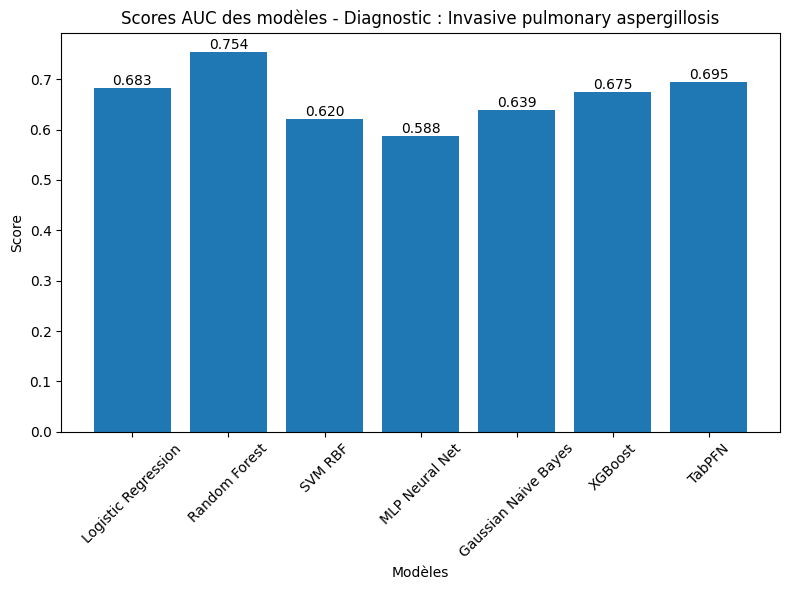


📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

==== Pneumocystis jirovecii infection ====
Logistic Regression AUC: 0.7002291447327678
Negative Predictive Value: 0
Random Forest AUC: 0.759707685638199
Negative Predictive Value: 1.0
SVM RBF AUC: 0.6437728370595157
Negative Predictive Value: 0
MLP Neural Net AUC: 0.6356351024958197
Negative Predictive Value: 0
Gaussian Naive Bayes AUC: 0.5577011209512603
Negative Predictive Value: 0.9444444444444444
XGBoost AUC: 0.6503251377964947
Negative Predictive Value: 0
TabPFN AUC: 0.7059020251439896
Negative Predictive Value: 0


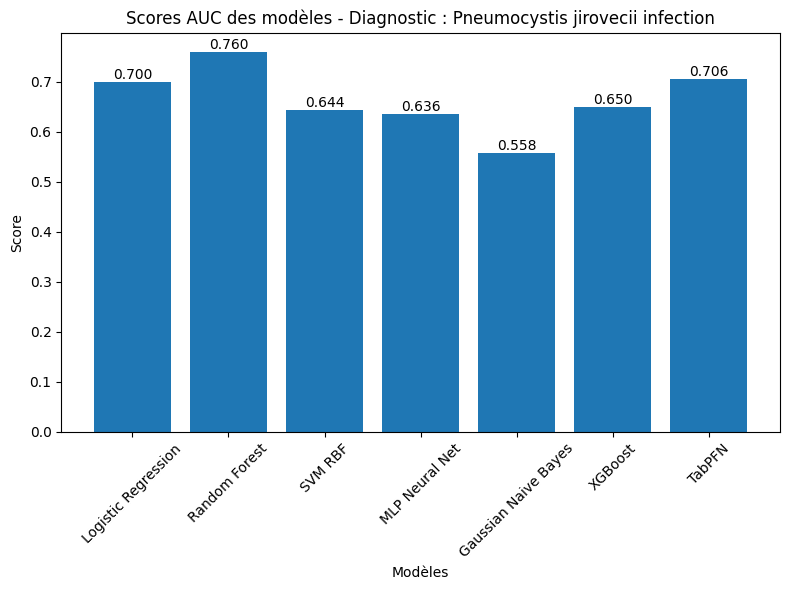


📊 Répartition des classes : pos=0.132, neg=0.868
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

==== Cardiogenic pulmonary oedema ====
Logistic Regression AUC: 0.7482854554865424
Negative Predictive Value: 0
Random Forest AUC: 0.7105277346445825
Negative Predictive Value: 0
SVM RBF AUC: 0.6970081737405107
Negative Predictive Value: 0
MLP Neural Net AUC: 0.6624180469289165
Negative Predictive Value: 0
Gaussian Naive Bayes AUC: 0.6548427795031057
Negative Predictive Value: 0
XGBoost AUC: 0.7112394323671497
Negative Predictive Value: 0
TabPFN AUC: 0.7177417615596963
Negative Predictive Value: 0


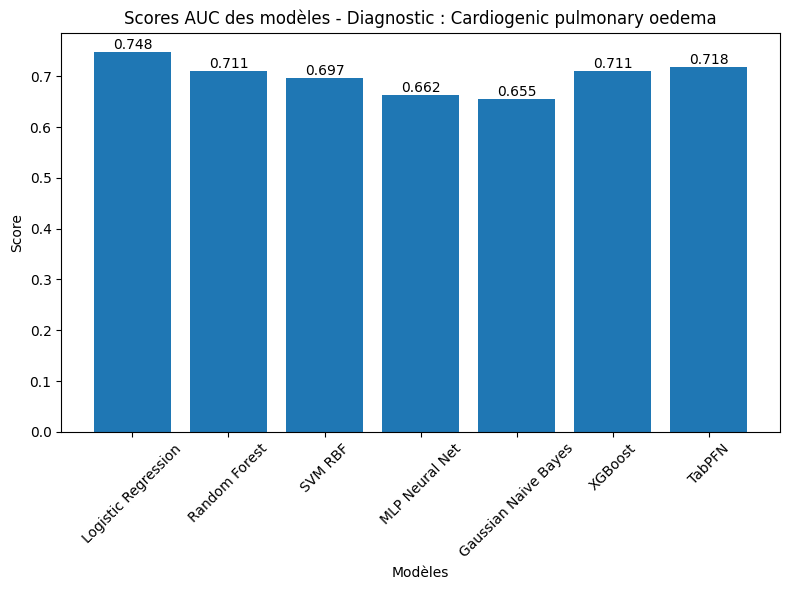

In [59]:
import huggingface_hub
huggingface_hub.login()

features_hemato =['Hem_mal_AML', 'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma',
       'Hem_mal_myeloma', 'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL',
       'Hem_mal_CML', 'Hem_mal_MDS', 'Hem_mal_other']

features_sensibilite = ["Neutropenie", "Prophylaxis_antifungal"]

diag_selected = [
    'Invasive pulmonary aspergillosis', 
    'Pneumocystis jirovecii infection',
    'Cardiogenic pulmonary oedema'
]
target_col = 'Cardiogenic pulmonary oedema'

MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'SVM RBF', 'MLP Neural Net', 'Gaussian Naive Bayes', 'XGBoost','TabPFN']
#MODEL_NAMES = ['TabPFN']
#MODEL_NAMES =  ['Logistic Regression']
MAIN_METRIC_NAME = 'roc_auc'
THRESHOLD = 0.11
for target_col in diag_selected:
    run_for_target(df_features_clean, 
                   df_labels_fusion, 
                   target_col,
                   MODEL_NAMES,
                   MAIN_METRIC_NAME,
                   THRESHOLD,
                   sensibilite = False,
                   features_sensibilite = features_sensibilite ,
                   type_sensi = 'all')


In [51]:
import huggingface_hub
huggingface_hub.login()

# Multioutput

In [2]:
from imblearn.pipeline import Pipeline
from utils.algo_prediction import preparer_jeu_xy

from utils.algo_prediction import AutoStandardScaler
from utils.models_and_metrics import get_models,get_metric,f1_metric_xgb
from utils.data_aug import get_augmentation_methods
from utils.visualisation import show_metrics_binary, show_roc_curve
from utils.models_and_metrics import negative_predictive_value
from sklearn.metrics import (roc_auc_score)
from utils.visualisation import multilabel_roc
import numpy as np
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean,df_labels_fusion) 

models = get_models(y_train,multilabel=True,imbalance_threshold=0.01,use_catboost=False)
augmentations = get_augmentation_methods(random_state=0)
print(augmentations.keys())

metrics = get_metric()
print(metrics.keys())

results = []
metrique = f1_metric_xgb
for model_name, model in models.items():
    print("Model:", model_name)
    
    pipe_train = Pipeline([
        ("scaler", AutoStandardScaler()),
        # ("augmentation", augmentations['SMOTE']),
        ("model",model )
    ])
    # Changement de la métrique plus tard
    # pipe_train.set_params(model__eval_metric=f1_metric_xgb)


    pipe_train.fit(X_train, y_train)

    metric_fn=metrics['roc_auc']["metric_fn"]
    needs_proba=metrics['roc_auc']["needs_proba"]


    pipe_test = Pipeline([
        ("scaler", pipe_train.named_steps["scaler"]),  # scaler déjà fit
        ("model", pipe_train.named_steps["model"])     # modèle déjà fit
    ])

    if needs_proba:
        y_pred = pipe_test.predict_proba(X_test)
    else:
        y_pred = pipe_test.predict(X_test)
    probas_array = np.column_stack([p[:, 1] for p in y_pred])

    a = multilabel_roc(
        np.array(y_test), probas_array,
        plot=True,
        label_names=y_test.columns.to_list(),
        per_label_max=8,   # ne tracer que les 8 meilleures courbes par label
        show_micro=True,
        show_macro=True
        )

    # score = roc_auc_score(y_test, y_pred, average="macro")
    # show_metrics_binary(y_test, y_pred)
    # show_roc_curve(y_test, y_pred)
    # print("Negative Predictive Value:", negative_predictive_value(y_test, y_pred))

NameError: name 'df_features_clean' is not defined

In [ ]:
from utils.models_and_metrics import get_models_multilabel, compare_models_metric, get_metric
from sklearn.metrics import hamming_loss
from sklearn.metrics import f1_score
from utils.algo_prediction import preparer_jeu_xy,normaliser_features,train_and_optimize_threshold_PR
# Charger les mod?les multilabel sp?cialis?s
models = get_models_multilabel()

metrics = get_metric()
# print(metrics['f1']'metric_fn')
# Pr?parer les donn?es
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean, df_labels_fusion)

# Comparer avec une m?trique multilabel
df_scores = compare_models_metric(
    models,
    metric_fn=f1_score,  # ou f1_score avec un autre average
    metric_kwargs={"average": "weighted"},
    metric_name="f1_weighted",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    needs_proba=False
)

print(df_scores)



🏷️ Mode MULTILABEL spécialisé : 7 modèles chargés


c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    6.5s finished
c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the conve

⚠️ MLkNN : erreur during training → ignoré.
'DataFrame' object has no attribute 'getformat'


c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   14.9s finished
c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the conve


🏆 CLASSEMENT DES MODÈLES PAR F1_WEIGHTED :

                   Modèle  f1_weighted
0             XGBoost OVR     0.356920
5          Label Powerset     0.355293
3       Classifier Chains     0.305704
2  Logistic Regression BR     0.300135
1       Random Forest OVR     0.296605
4                   RAkEL     0.294989
                   Modèle  f1_weighted
0             XGBoost OVR     0.356920
5          Label Powerset     0.355293
3       Classifier Chains     0.305704
2  Logistic Regression BR     0.300135
1       Random Forest OVR     0.296605
4                   RAkEL     0.294989


c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.0min finished
c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


# SHAP values

In [ ]:
sys.modules.pop('utils.feature_importance', None)
from utils.feature_importance import shap_top10_per_estimator,plot_top10_features_per_estimator
plot_top10_features_per_estimator(modele,feature_names=X_train.columns,col_names=y_train.columns,to_save=True,dir_save='E:/graphs_bdd/importance')
shap_top10_per_estimator(model= modele,X = X_test_sc,col_names=y_train.columns,to_save=True,dir_save='E:/graphs_bdd/shap')

In [ ]:
from utils.stats_dataset import analyze_collinearity
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
Liste_features = Liste_features_simple #+ features_radiology_dysfunction
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
df_col_utils = _convert_all_columns_to_numeric(df_col_utils)
# print(df_col_utils.columns)

df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)

df_category = nettoyer_colonnes(df_category)
df_cat_clean = nettoyer_lignes_vides(df_category)
df_col_utils = nettoyer_lignes_vides(df_col_utils)
vif_results = analyze_collinearity(df_col_utils)
vif_results_clean = analyze_collinearity(df_features_clean)




In [ ]:
df_col_utils.isna().any().any()
# print(df_features_clean.isna().sum()[df_features_clean.isna().sum() > 0])


In [ ]:
L_radio = ['Alveolar_xray_No', 'Alveolar_xray_Focal',
       'Alveolar_xray_Diffuse', 'Interst_xray_No', 'Interst_xray_Focal',
       'Interst_xray_Diffuse', 'Alveolar_cons_No', 'Alveolar_cons_Focal',
       'Alveolar_cons_Diffuse', 'Ground_glass_op_No', 'Ground_glass_op_Focal',
       'Ground_glass_op_Diffuse', 'rejet_allograft', 'HSCT_BMT_Autograft',
       'HSCT_BMT_Allograft', 'SOFA_scaled', 'Sa02', 'Resp_severity',
       'Temp_gravité', 'Neutropenie']
for x in L_radio:
    print(df_features_clean[x].value_counts())

In [ ]:
df_features_clean.iloc[0]

In [ ]:
Implémenter from sklearn.model_selection import StratifiedKFold
